In [1]:
import os
import sys

import numpy as np
import math

# Plotting
import cmocean
import cmocean.cm as cmo
import cmasher as cmr
import seaborn as sns
import pylab as plt
import matplotlib as mpl
import matplotlib.pyplot as pyplot
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
import matplotlib.colors as mc
import colorsys


In [3]:
plt.rcParams['font.size'] = '12'
plt.rcParams['savefig.facecolor']='white'
plt.rcParams['axes.titlepad'] = 16
# plt.rcParams.update({
    # "text.usetex": True,
    # "font.family": "serif"
# })
plt.rcParams["errorbar.capsize"] = 5

In [4]:
def lighten(color, amount=0.5):
    """
    Lightens the given color by mixing it with white.
    amount=0 → original colour
    amount=1 → fully white
    
    """
    try:
        c = mc.cnames[color]
    except:
        c = color
    rgb = mc.to_rgb(c)
    return tuple(1 - amount*(1 - x) for x in rgb)

In [5]:
def phase(thetas, ws, gs):
    phase_func = np.sum([w * (1/(4*math.pi)) * (1 - g**2) / ((1 + g**2 - 2*g * np.cos(thetas))**(3/2)) for w, g in zip(ws, gs)], axis=0)
    
    return phase_func

In [6]:
def k98(thetas, cs):
    c0, c1, c2 = cs

    exp_term = (np.exp(c2*np.pi) + 1) / (c2**2 + 1)    
    S = 2*c0 + np.pi*c1 + exp_term
    
    N = 1.0 / (2*np.pi * S)

    phase_func = N * (c0 + c1*thetas + np.exp(c2*thetas))
   
    return phase_func

In [6]:
# def A(g, thetas):
#     # g: (n,) or (n,1) ; thetas: (m,) or (m,)
#     # result shape: (n, m)
#     C = 1./(4*np.pi)
#     S = 1 + g**2 - 2*g*np.cos(thetas)
#     return C * (1 - g**2) / (S**(3/2))

# def dA_dg(g, thetas):
#     C = 1./(4*np.pi)
#     cos_t = np.cos(thetas)
#     S = 1 + g**2 - 2*g*cos_t
#     num = 2*g*S + 3*(1 - g**2)*(g - cos_t)
#     return -C * num / (S**(5/2))

# def phase_and_error(thetas, ws, gs, sigma_ws, sigma_gs):
#     # thetas: (m,), ws,gs,sigma_*: (n,)
#     thetas = np.asarray(thetas)
#     gs_col = gs[:, None]          # (n,1)
#     ws_col = ws[:, None]          # (n,1)
#     sigma_w_col = sigma_ws[:, None]
#     sigma_g_col = sigma_gs[:, None]

#     Avals = A(gs_col, thetas)            # (n,m)
#     dAvals = dA_dg(gs_col, thetas)       # (n,m)

#     phase_components = ws_col * Avals    # (n,m)
#     phase_func = np.sum(phase_components, axis=0)      # (m,)

#     var_ws = (Avals * sigma_w_col)**2        # (n,m)
#     var_gs = (ws_col * dAvals * sigma_g_col)**2
#     var_phi = np.sum(var_ws + var_gs, axis=0)  # (m,)
#     sigma_phi = np.sqrt(var_phi)

#     integral = np.trapezoid(phase_func, thetas)
#     phase_norm = phase_func / integral

#     return phase_norm, sigma_phi

In [7]:
def trapz_weights(x):
    x = np.asarray(x)
    m = len(x)
    if m < 2:
        return np.array([1.0])
    dx = np.diff(x)
    w = np.empty(m)
    w[0] = dx[0]/2.0
    w[-1] = dx[-1]/2.0
    w[1:-1] = 0.5*(dx[:-1] + dx[1:])
    return w

# A(g,theta) and derivative dA/dg (from earlier)
def A_of_g(g, thetas):
    C = 1.0/(4*np.pi)
    S = 1 + g**2 - 2*g*np.cos(thetas)
    return C * (1 - g**2) / (S**1.5)

def dA_dg(g, thetas):
    C = 1.0/(4*np.pi)
    cos_t = np.cos(thetas)
    S = 1 + g**2 - 2*g*cos_t
    num = 2*g*S + 3*(1 - g**2)*(g - cos_t)
    return -C * num / (S**2.5)

def analytic_phase_and_error(thetas, ws, gs, sigma_ws, sigma_gs, cov_param=None):
    """
    thetas: (n_thetas,)
    ws, gs, sigma_*: (n_ws,)
    cov_p: optional covariance matrix for parameters of shape (2*n_ws,2*n_ws).
           If None, parameters are assumed independent -> diagonal cov from sigma_ws and sigma_gs.
    Returns: phase_norm (n_thetas,), sigma_phase_norm (n_thetas,)
    """
    thetas = np.asarray(thetas)
    n_ws = len(ws) #n
    n_thetas = len(thetas) #m

    # unnormalised phase
    gs_col = gs[:, None]    # (n,1)
    ws_col = ws[:, None]
    Avals = A_of_g(gs_col, thetas)       # (n_ws,n_thetas)
    dAvals = dA_dg(gs_col, thetas)      # (n_ws,n_thetas)
    phase_components = ws_col * Avals   # (n_ws,n_thetas)
    phase_func = np.sum(phase_components, axis=0)  # (n_thetas,)

    # trapezoid weights and integral
    weighted_trap = trapz_weights(thetas)       # (n_thetas,)
    integral = np.dot(weighted_trap, phase_func)

    # Build Jacobian J (n_thetas x P) where P = 2*n_ws (w1..wn, g1..gn)
    P = 2*n_ws
    jacobian = np.zeros((n_thetas, P))
    # derivatives wrt w_i: d f / d w_i = A(g_i, theta)  -> shape (n_thetas,)
    for i in range(n_ws):
        jacobian[:, i] = Avals[i]       # column for w_i
        
    # derivatives wrt g_i: d f / d g_i = w_i * dA_dg(g_i,theta)
    for i in range(n_ws):
        jacobian[:, n_ws + i] = ws[i] * dAvals[i]

    # parameter covariance
    if cov_param is None:
        cov_param = np.zeros((P, P))
        cov_param[np.arange(n_ws), np.arange(n_ws)] = sigma_ws**2
        cov_param[n_ws + np.arange(n_ws), n_ws + np.arange(n_ws)] = sigma_gs**2
        # off-diagonal covariances = 0

    # Covariance of f
    cov_phase_raw = jacobian @ cov_param @ jacobian.T    # (m,m)

    # Build M matrix for normalisation: M = (I*I_m - f w^T) / I^2
    norm_matrix = (integral * np.eye(n_thetas) - np.outer(phase_func, weighted_trap)) / (integral**2)

    # Covariance of normalised phase
    cov_phase_norm = norm_matrix @ cov_phase_raw @ norm_matrix.T    # (m,m)
    sigma_phase = np.sqrt(np.clip(np.diag(cov_phase_norm), 0.0, None))

    # normalised phase
    phase_norm = phase_func / integral

    return phase_norm, sigma_phase

In [8]:
def normalise(phase_func, thetas):
    integral = np.trapezoid(phase_func, thetas)
    phase_norm = phase_func / integral
    return phase_norm
    

In [9]:
def sample_phase(thetas, dat, ws_nom, gs_nom, sigma_ws, sigma_gs,):

    # rng = np.random.default_rng(seed)
    n = len(ws_nom)
    n_thetas = len(thetas)

    # Nominal (theory) curve
    phase_nom = normalise(phase(thetas, ws_nom, gs_nom), thetas)

    # Note: ws[0] is dependent: ws0 = 1 - (ws1 - ws2)
    # w_draws = rng.normal(ws_nom, sigma_ws, size=(ndraws, n))
    # g_draws = rng.normal(gs_nom, sigma_gs, size=(ndraws, n))

    g_samples = dat[:,0:3]
    w_samples = np.zeros_like(g_samples)
    w_samples[:,1:3] = dat[:,3:5]

    n_samples = dat.shape[0]

    phases = np.empty((n_samples, n_thetas))
    for i in range(n_samples):
        ws_i = w_samples[i].copy()
        gs_i = g_samples[i]

        # ensure dependent relation in each draw 
        ws_i[0] = 1 - (ws_i[1] - ws_i[2])

        phase_func = phase(thetas, ws_i, gs_i)
        phases[i] = normalise(phase_func, thetas)

    median = np.median(phases, axis=0)
    p16 = np.percentile(phases, 16, axis=0)
    p84 = np.percentile(phases, 84, axis=0)
    mean = np.mean(phases, axis=0)
    std = np.std(phases, axis=0, ddof=1)

    return {
        "phase_normalised": phase_nom,
        "phase_mean": mean,
        "phase_median": median,
        "phase_std": std,
        "phase_p16": p16,
        "phase_p84": p84,
        # "phases": phases   
    }

In [10]:
# Our params 
dat = np.loadtxt('phase_fun_pars.dat') #G1, G2, G3, W2, W3

thetas_deg = np.arange(68, 126, 1)
thetas = thetas_deg * np.pi/180  

gs = np.array([1.154e-01, -4.377e-01, -8.800e-01])
ws = np.array([0., 2.070e-01, 5.004e-03])
ws[0] = 1 - (ws[1]-ws[2])

gs_rms = np.array([3.121e-02, 4.035e-02, 7.990e-02])
ws_rms = np.array([0., 3.020e-02, 1.250e-05])
ws_rms[0] = np.sqrt(ws_rms[1]**2 + ws_rms[2]**2)

In [11]:
# Hong 1985 model
gs_hong = np.array([0.70, -0.20, -0.81])
ws_hong = np.array([0.665, 0.330, 0.005])

phase_hong = normalise(phase(thetas, ws_hong, gs_hong), thetas)

In [12]:
# K98 model 
cs_1 = np.array([-0.942, 0.121, -0.165]) # 1.25 um
cs_2 = np.array([-0.527, 0.187, -0.590]) # 2.2 um
cs_3 = np.array([-0.431, 0.172, -0.633]) # 3.5 um 

phase_k98_1 = normalise(k98(thetas, cs_1), thetas)
phase_k98_2 = normalise(k98(thetas, cs_2), thetas)
phase_k98_3 = normalise(k98(thetas, cs_3), thetas)

In [13]:
# SKYSURF phase function in DIRBE band 1 (1.25 um) [it's like Hong but with parameters multiplied by wavelength]
wvl = 1.25 #um
gs_surf = np.array([(0.250*wvl)+0.116, (0.054*wvl)-0.309, -0.870])
ws_surf = np.array([(0.0018*wvl)+0.0478, (-0.0014*wvl)+0.0312, 0.0003])

phase_surf = normalise(phase(thetas, ws_surf, gs_surf), thetas)

### Unnormalised phase function

The multi–component Henyey–Greenstein phase function is

$
f(\theta) \;=\; 
\sum_{i=1}^3 
w_i \; \frac{1}{4\pi} 
\frac{1 - g_i^2}{\left( 1 + g_i^2 - 2g_i\cos\theta \right)^{3/2}} .
$

Here  
- $w_i$ are the weights,
- $g_i$ are the asymmetry parameters,
- $\theta$ is the scattering angle.

### Normalisation

The normalised phase function is

$
\Phi(\theta) = \dfrac{f(\theta)}{\int f(\theta)\, d\theta } .
$

In practice (discrete sampling):

$
\Phi(\theta_j) = 
\dfrac{ f(\theta_j) }
     { \sum_k f(\theta_k)\,\Delta\theta_k } .
$

### Monte-Carlo error propagation

To propagate the uncertainties on $w_i$ and $g_i$, we draw parameters

$
w_i^{(n)} \sim \mathcal{N}(w_i,\,\sigma_{w_i}),
\qquad
g_i^{(n)} \sim \mathcal{N}(g_i,\,\sigma_{g_i}),
$

compute the corresponding normalised phase function

$
\Phi^{(n)}(\theta)
= \dfrac{ f\!\left(\theta\,|\,w^{(n)},g^{(n)}\right) }
       { \int f\!\left(\theta\,|\,w^{(n)},g^{(n)}\right)\, d\theta},
$

and estimate

$\langle \Phi(\theta) \rangle$ and $\sigma_{\Phi}(\theta)$

from the sample median and error (16th and 84th percentiles) over all Monte-Carlo trials.

### Plot everything:

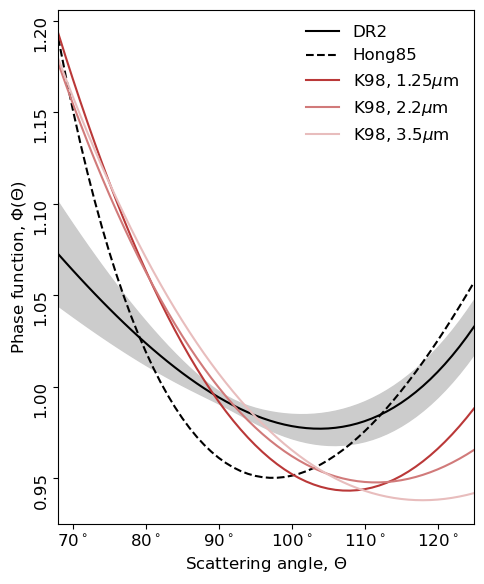

In [13]:
# Error propagation and normalisation
res = sample_phase(thetas, dat, ws, gs, ws_rms, gs_rms)

phase_comm = res["phase_normalised"]
phase_up = res["phase_normalised"]+res["phase_std"]
phase_down = res["phase_normalised"]-res["phase_std"]

# Plot section
fig, ax = plt.subplots(figsize=(5,6))
# plt.yscale('log')

ax.fill_between(thetas_deg, phase_up, phase_down, color='0.8')#, zorder=6)
# ax.plot(thetas_deg,phase_up)
# ax.plot(thetas_deg,phase_down)
ax.plot(thetas_deg,(phase_comm), color='black', label='DR2')#, zorder=6)

ax.plot(thetas_deg,(phase_hong), color='black', ls='--', label='Hong85')#, zorder=0)
ax.plot(thetas_deg,(phase_k98_1), color=lighten('firebrick',0.9), ls='-', label=r'K98, $1.25\mu$m')#, alpha=0.9)#, zorder=0)
ax.plot(thetas_deg,(phase_k98_2), color=lighten('firebrick',0.6), ls='-', label=r'K98, $2.2\mu$m')#, alpha=0.6)#, zorder=0)
ax.plot(thetas_deg,(phase_k98_3), color=lighten('firebrick',0.3), ls='-', label=r'K98, $3.5\mu$m')#, alpha=0.3)#, zorder=0)

ax.set_xlabel(r'Scattering angle, $\Theta$')
ax.set_ylabel(r'Phase function, $\Phi(\Theta)$')

plt.setp(ax.get_yticklabels(), rotation=90)

plt.legend(frameon=False)
# plt.ylim([0,2])
ax.set_xlim([68,125])
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: rf'{int(x)}$^\circ$')
)

filetypes = ['.png', '.pdf']
plt.tight_layout()
for filetype in filetypes:
    fig.savefig('phase_function_std'+filetype, 
                bbox_inches='tight', 
                #transparent=True, 
                dpi=300,#fig.dpi,
                facecolor='white')

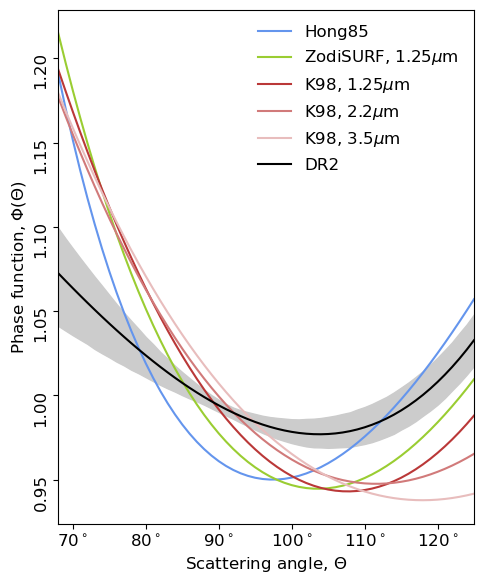

In [20]:
# Error propagation and normalisation
res = sample_phase(thetas, dat, ws, gs, ws_rms, gs_rms)

phase_comm = res["phase_normalised"]
phase_up = res["phase_p84"]
phase_down = res["phase_p16"]

# Plot section
fig, ax = plt.subplots(figsize=(5,6))
# plt.yscale('log')



ax.plot(thetas_deg,(phase_hong), color='cornflowerblue', ls='-', label='Hong85')#, zorder=0)
ax.plot(thetas_deg,(phase_surf), color='yellowgreen', ls='-', label='ZodiSURF, $1.25\mu$m')
ax.plot(thetas_deg,(phase_k98_1), color=lighten('firebrick',0.9), ls='-', label=r'K98, $1.25\mu$m')#, alpha=0.9)#, zorder=0)
ax.plot(thetas_deg,(phase_k98_2), color=lighten('firebrick',0.6), ls='-', label=r'K98, $2.2\mu$m')#, alpha=0.6)#, zorder=0)
ax.plot(thetas_deg,(phase_k98_3), color=lighten('firebrick',0.3), ls='-', label=r'K98, $3.5\mu$m')#, alpha=0.3)#, zorder=0)

ax.fill_between(thetas_deg, phase_up, phase_down, color='0.8')#, zorder=6)
# ax.plot(thetas_deg,phase_up)
# ax.plot(thetas_deg,phase_down)
ax.plot(thetas_deg,(phase_comm), color='black', label='DR2')#, zorder=6)

ax.set_xlabel(r'Scattering angle, $\Theta$')
ax.set_ylabel(r'Phase function, $\Phi(\Theta)$')

plt.setp(ax.get_yticklabels(), rotation=90)

plt.legend(frameon=False)
# plt.ylim([0,2])
ax.set_xlim([68,125])
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: rf'{int(x)}$^\circ$')
)

filetypes = ['.png', '.pdf']
plt.tight_layout()
for filetype in filetypes:
    fig.savefig('phase_function_norm'+filetype, 
                bbox_inches='tight', 
                #transparent=True, 
                dpi=300,#fig.dpi,
                facecolor='white')

### alternative analytic covariance propagation (Jacobian method)

We can write the unnormalised phase function as

$
f(\theta)
= \sum_{i=1}^{N}
w_i \, A(g_i, \theta),\qquad N=3
$

where

$
A(g,\theta)
= \dfrac{1}{4\pi}
\dfrac{1 - g^2}
{\left(1 + g^2 - 2g\cos\theta\right)^{3/2}} .
$

Let the parameter vector be

$
\mathbf{p} = (w_1,\ldots,w_N, g_1,\ldots,g_N).
$

The Jacobian of the unnormalised phase function is

$
J_{j,i}
= \dfrac{\partial f(\theta_j)}{\partial p_i}.
$

Given a parameter covariance matrix $\mathbf{C}_p$,  
the covariance of the unnormalised phase vector is

$
\mathbf{C}_f
= \mathbf{J}\,\mathbf{C}_p\,\mathbf{J}^{\mathsf{T}}.
$

Normalisation introduces the transformation

$
\Phi = \dfrac{f}{I},
\qquad
I = \mathbf{w}^{\mathsf{T}} f,
$

giving the covariance of the normalised function:

$
\mathbf{C}_\Phi
= \mathbf{M}\, \mathbf{C}_f \, \mathbf{M}^{\mathsf{T}},
$

where

$
\mathbf{M}
= \dfrac{I\,\mathbf{I} - f\,\mathbf{w}^{\mathsf{T}}}{I^2}.
$

In [15]:
def trapz_weights(x):
    x = np.asarray(x)
    m = len(x)
    if m < 2:
        return np.array([1.0])
    dx = np.diff(x)
    w = np.empty(m)
    w[0] = dx[0]/2.0
    w[-1] = dx[-1]/2.0
    w[1:-1] = 0.5*(dx[:-1] + dx[1:])
    return w

# A(g,theta) and derivative dA/dg 
def A_of_g(g, thetas):
    C = 1.0/(4*np.pi)
    S = 1 + g**2 - 2*g*np.cos(thetas)
    return C * (1 - g**2) / (S**1.5)

def dA_dg(g, thetas):
    C = 1.0/(4*np.pi)
    cos_t = np.cos(thetas)
    S = 1 + g**2 - 2*g*cos_t
    num = 2*g*S + 3*(1 - g**2)*(g - cos_t)
    return -C * num / (S**2.5)

def analytic_phase_and_error(thetas, ws, gs, sigma_ws, sigma_gs):
    """
    thetas: (n_thetas,)
    ws, gs, sigma_*: (n_ws,)
    Returns: phase_norm (n_thetas,), sigma_phase_norm (n_thetas,)
    """
    thetas = np.asarray(thetas)
    n_ws = len(ws) #n
    n_thetas = len(thetas) #m

    # unnormalised phase
    gs_col = gs[:, None]    # (n,1)
    ws_col = ws[:, None]
    Avals = A_of_g(gs_col, thetas)       # (n_ws,n_thetas)
    dAvals = dA_dg(gs_col, thetas)      # (n_ws,n_thetas)
    phase_components = ws_col * Avals   # (n_ws,n_thetas)
    phase_func = np.sum(phase_components, axis=0)  # (n_thetas,)

    # trapezoid weights and integral
    weighted_trap = trapz_weights(thetas)       # (n_thetas,)
    integral = np.dot(weighted_trap, phase_func)

    # Build Jacobian J (n_thetas x P) where P = 2*n_ws (w1..wn, g1..gn)
    P = 2*n_ws
    jacobian = np.zeros((n_thetas, P))
    # derivatives wrt w_i: d f / d w_i = A(g_i, theta)  -> shape (n_thetas,)
    for i in range(n_ws):
        jacobian[:, i] = Avals[i]       # column for w_i
        
    # derivatives wrt g_i: d f / d g_i = w_i * dA_dg(g_i,theta)
    for i in range(n_ws):
        jacobian[:, n_ws + i] = ws[i] * dAvals[i]

    # parameter covariance, parameters are assumed independent -> diagonal cov from sigma_ws and sigma_gs.
    cov_param = np.zeros((P, P))
    cov_param[np.arange(n_ws), np.arange(n_ws)] = sigma_ws**2
    cov_param[n_ws + np.arange(n_ws), n_ws + np.arange(n_ws)] = sigma_gs**2
    # off-diagonal covariances = 0

    # Covariance of f
    cov_phase_raw = jacobian @ cov_param @ jacobian.T    # (m,m)

    # Build M matrix for normalisation: M = (I*I_m - f w^T) / I^2
    norm_matrix = (integral * np.eye(n_thetas) - np.outer(phase_func, weighted_trap)) / (integral**2)

    # Covariance of normalised phase
    cov_phase_norm = norm_matrix @ cov_phase_raw @ norm_matrix.T    # (m,m)
    sigma_phase = np.sqrt(np.clip(np.diag(cov_phase_norm), 0.0, None))

    # normalised phase
    phase_norm = phase_func / integral

    return phase_norm, sigma_phase

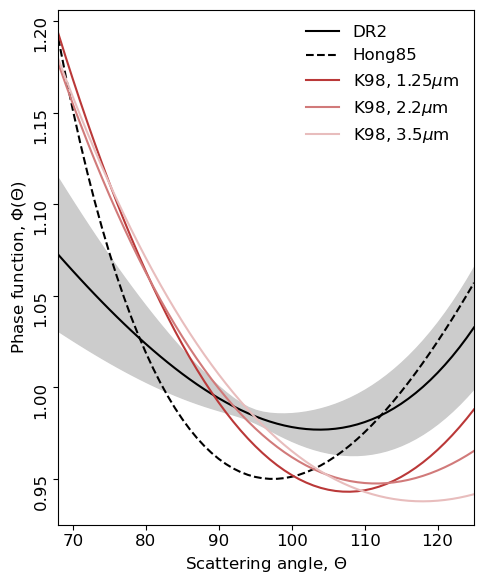

In [16]:
# Error propagation and normalisation
phase_norm, sigma_phase = analytic_phase_and_error(thetas, ws, gs, ws_rms, gs_rms)

phase_comm = phase_norm
phase_up = phase_norm + sigma_phase
phase_down = phase_norm - sigma_phase

# Plot section
fig, ax = plt.subplots(figsize=(5,6))
# plt.yscale('log')

ax.fill_between(thetas_deg, phase_up, phase_down, color='0.8')#, zorder=6)
# ax.plot(thetas_deg,phase_up)
# ax.plot(thetas_deg,phase_down)
ax.plot(thetas_deg,(phase_comm), color='black', label='DR2')#, zorder=6)

ax.plot(thetas_deg,(phase_hong), color='black', ls='--', label='Hong85')#, zorder=0)
ax.plot(thetas_deg,(phase_k98_1), color=lighten('firebrick',0.9), ls='-', label=r'K98, $1.25\mu$m')#, alpha=0.9)#, zorder=0)
ax.plot(thetas_deg,(phase_k98_2), color=lighten('firebrick',0.6), ls='-', label=r'K98, $2.2\mu$m')#, alpha=0.6)#, zorder=0)
ax.plot(thetas_deg,(phase_k98_3), color=lighten('firebrick',0.3), ls='-', label=r'K98, $3.5\mu$m')#, alpha=0.3)#, zorder=0)

ax.set_xlabel(r'Scattering angle, $\Theta$')
ax.set_ylabel(r'Phase function, $\Phi(\Theta)$')

plt.setp(ax.get_yticklabels(), rotation=90)

plt.legend(frameon=False)
# plt.ylim([0,2])
ax.set_xlim([68,125])
ax.xaxis.set_major_locator(MultipleLocator(10))

filetypes = ['.png', '.pdf']
plt.tight_layout()
for filetype in filetypes:
    fig.savefig('phase_function_jacobian'+filetype, 
                bbox_inches='tight', 
                #transparent=True, 
                dpi=300,#fig.dpi,
                facecolor='white')